# ABC Model

A three-variable ODE with:
- **Negative feedback loop** between A and B (integral feedback)
- **Tumor dynamics** driven by B

## Equations

$$\frac{dA}{dt} = a_1(\mu - B)$$

$$\frac{dB}{dt} = b_1 A - b_2 B$$

$$\frac{dC}{dt} = C\bigl(c_1 - c_2 \max(\mu - B,\, 0)\bigr)$$

**Interpretation:**
- $A$: compensatory adaptation
- $B$: cancer-supporting TME component (setpoint $\mu$)
- $C$: tumor size

**Topology:**
- $A$ activates $B$ (via $b_1 A$); $B$ inhibits $A$ (integral feedback) → $B_{ss} = \mu$
- Tumor grows at rate $c_1$; removal $c_2 \max(\mu-B, 0)$ is only active when $B < \mu$
- Treatment reduces $b_1$, pushing $B$ below $\mu$ and enabling tumor removal

**Steady states (off treatment):**
$$B_{ss} = \mu, \quad A_{ss} = \frac{b_2\,\mu}{b_1}$$

Off treatment: $B = \mu$ so $\max(\mu-B,0)=0$ and tumor grows at rate $c_1$.  
On treatment: $B < \mu$ and tumor removal $c_2(\mu-B)$ can overcome growth.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import sys
sys.path.insert(0, '../src')
from rpa_control.style import set_style

set_style()
plt.rcParams['text.usetex'] = False

def clean_ax(ax):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

In [4]:
# ======================================================================
# Parameters
# ======================================================================

mu = 1.0

# AB parameters
a1 = 1.0
b1 = 1.0   # A → B activation (halved by treatment)
b2 = 2.0

# C parameters
c1 = 0.1   # tumor growth rate
c2 = 1.0   # tumor removal rate (active when B < mu)

# Off-treatment steady states (B=mu by integral feedback)
B_ss = mu
A_ss = b2 * mu / b1

print(f"Off-treatment steady state: A={A_ss:.2f}, B={B_ss:.2f}")
print(f"Off-treatment: tumor grows at rate c1={c1} (no removal since B=mu)")

# Treatment: halve b1
b1_on = b1 / 2
A_ss_on = b2 * mu / b1_on
print(f"\nOn-treatment steady state (AB): A={A_ss_on:.2f}, B={B_ss:.2f}")
print(f"On-treatment: B transiently dips below mu → tumor removal active")

Off-treatment steady state: A=2.00, B=1.00
Off-treatment: tumor grows at rate c1=0.1 (no removal since B=mu)

On-treatment steady state (AB): A=4.00, B=1.00
On-treatment: B transiently dips below mu → tumor removal active


In [5]:
# ======================================================================
# ODE definition
# ======================================================================

def abc_rhs(t, y, b1_val):
    A, B, C = y
    dA = a1 * (mu - B)
    dB = b1_val * A - b2 * B
    dC = C * (c1 - c2 * max(mu - B, 0))
    return [dA, dB, dC]

In [6]:
# ======================================================================
# Simulation: start at off-treatment SS, apply treatment, then release
# ======================================================================

from scipy.integrate import odeint

# Initial condition: off-treatment steady state, tumor at C=1
y0 = [A_ss, B_ss, 1.0]

t_treatment = 10.0   # apply treatment at t=0, release at t=10
t_end       = 30.0   # end simulation at t=30

t1 = np.linspace(0, t_treatment, 300)
t2 = np.linspace(0, t_end - t_treatment, 600)

# Phase 1: on treatment (b1 halved)
sol1 = odeint(lambda y, t: abc_rhs(t, y, b1_on), y0, t1)
A1, B1, C1 = sol1.T

# Phase 2: off treatment (b1 restored)
sol2 = odeint(lambda y, t: abc_rhs(t, y, b1), sol1[-1], t2)
A2, B2, C2 = sol2.T

t_full = np.concatenate([t1, t_treatment + t2[1:]])
A_full = np.concatenate([A1, A2[1:]])
B_full = np.concatenate([B1, B2[1:]])
C_full = np.concatenate([C1, C2[1:]])

print("Simulation complete.")
print(f"  Final state: A={A_full[-1]:.3f}, B={B_full[-1]:.3f}, C={C_full[-1]:.3f}")

Simulation complete.
  Final state: A=2.000, B=1.000, C=3.092


/tmp/ipykernel_2356301/2918764802.py:36: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


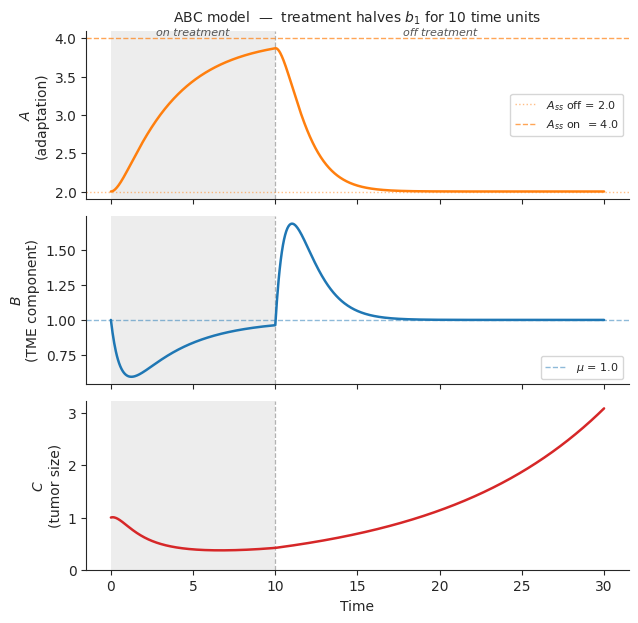

In [7]:
# ======================================================================
# Plot
# ======================================================================

fig, axes = plt.subplots(3, 1, figsize=(7, 7), sharex=True,
                          gridspec_kw={'hspace': 0.1})

for ax in axes:
    ax.axvspan(0, t_treatment, color='lightgray', alpha=0.4, lw=0, zorder=0)
    ax.axvline(t_treatment, color='gray', ls='--', lw=0.9, alpha=0.6)
    clean_ax(ax)

axes[0].plot(t_full, A_full, color='C1', lw=1.8)
axes[0].axhline(A_ss,    color='C1', ls=':', lw=1.0, alpha=0.5, label=f'$A_{{ss}}$ off = {A_ss:.1f}')
axes[0].axhline(A_ss_on, color='C1', ls='--', lw=1.0, alpha=0.7, label=f'$A_{{ss}}$ on  = {A_ss_on:.1f}')
axes[0].set_ylabel('$A$\n(adaptation)')
axes[0].legend(fontsize=8, loc='center right')

axes[1].plot(t_full, B_full, color='C0', lw=1.8)
axes[1].axhline(B_ss, color='C0', ls='--', lw=1.0, alpha=0.5, label=f'$\\mu$ = {mu:.1f}')
axes[1].set_ylabel('$B$\n(TME component)')
axes[1].legend(fontsize=8, loc='lower right')

axes[2].plot(t_full, C_full, color='C3', lw=1.8)
axes[2].set_ylabel('$C$\n(tumor size)')
axes[2].set_xlabel('Time')
axes[2].set_ylim(bottom=0)

trans = axes[0].get_xaxis_transform()
kw = dict(ha='center', va='bottom', fontsize=8, color='#555555', fontstyle='italic', transform=trans)
axes[0].text(t_treatment / 2,                     0.96, 'on treatment', **kw)
axes[0].text((t_treatment + t_end) / 2,           0.96, 'off treatment', **kw)

axes[0].set_title(f'ABC model  —  treatment halves $b_1$ for {int(t_treatment)} time units', fontsize=10)

plt.tight_layout()
fig.savefig('abc_model_treatment.pdf', bbox_inches='tight')
plt.show()

/tmp/ipykernel_2356301/4203207906.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


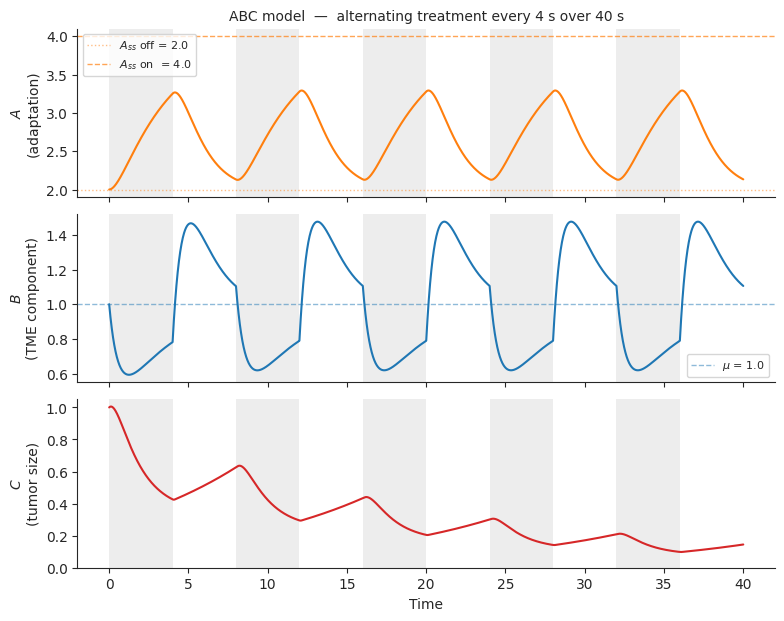

In [8]:
# ======================================================================
# Alternating treatment: switch every 4 seconds for 40 seconds total
# ======================================================================

t_switch = 4.0
t_total  = 40.0
n_cycles = int(t_total / t_switch)

t_all = []
A_all = []
B_all = []
C_all = []

y_cur = [A_ss, B_ss, 1.0]   # start at off-treatment SS
t_cur = 0.0

for i in range(n_cycles):
    b1_cur = b1_on if (i % 2 == 0) else b1   # start on treatment
    t_seg = np.linspace(0, t_switch, 200)
    sol = odeint(lambda y, t: abc_rhs(t, y, b1_cur), y_cur, t_seg)
    t_all.append(t_cur + t_seg)
    A_all.append(sol[:, 0])
    B_all.append(sol[:, 1])
    C_all.append(sol[:, 2])
    t_cur += t_switch
    y_cur = sol[-1]

t_cyc = np.concatenate(t_all)
A_cyc = np.concatenate(A_all)
B_cyc = np.concatenate(B_all)
C_cyc = np.concatenate(C_all)

# --- plot ---
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True,
                          gridspec_kw={'hspace': 0.1})

# shade treatment periods (even cycles)
for i in range(n_cycles):
    if i % 2 == 0:
        for ax in axes:
            ax.axvspan(i * t_switch, (i + 1) * t_switch,
                       color='lightgray', alpha=0.4, lw=0, zorder=0)

for ax in axes:
    clean_ax(ax)

axes[0].plot(t_cyc, A_cyc, color='C1', lw=1.5)
axes[0].axhline(A_ss,    color='C1', ls=':', lw=1.0, alpha=0.5, label=f'$A_{{ss}}$ off = {A_ss:.1f}')
axes[0].axhline(A_ss_on, color='C1', ls='--', lw=1.0, alpha=0.7, label=f'$A_{{ss}}$ on  = {A_ss_on:.1f}')
axes[0].set_ylabel('$A$\n(adaptation)')
axes[0].legend(fontsize=8, loc='upper left')

axes[1].plot(t_cyc, B_cyc, color='C0', lw=1.5)
axes[1].axhline(B_ss, color='C0', ls='--', lw=1.0, alpha=0.5, label=f'$\\mu$ = {mu:.1f}')
axes[1].set_ylabel('$B$\n(TME component)')
axes[1].legend(fontsize=8, loc='lower right')

axes[2].plot(t_cyc, C_cyc, color='C3', lw=1.5)
axes[2].set_ylabel('$C$\n(tumor size)')
axes[2].set_xlabel('Time')
axes[2].set_ylim(bottom=0)

axes[0].set_title(f'ABC model  —  alternating treatment every {t_switch:.0f} s over {t_total:.0f} s', fontsize=10)

plt.tight_layout()
fig.savefig('abc_model_cycling.pdf', bbox_inches='tight')
plt.show()

# Analytical Analysis of the ABC Model

## Tumor Shrinkage Condition Over a Treatment Cycle

We start with the equation for tumor dynamics:
$$\frac{dC}{dt} = C\bigl(c_1 - c_2 \max(\mu - B,\, 0)\bigr)$$

Since the tumor size $C$ is strictly positive ($C > 0$), we can divide by $C$ to isolate the per capita growth rate. We will use the shorthand $(\mu - B)^+$ for $\max(\mu - B,\, 0)$:
$$\frac{1}{C}\frac{dC}{dt} = c_1 - c_2 (\mu - B)^+$$

Next, we integrate this equation over a single full treatment cycle of duration $T$, from $t = 0$ to $t = T$. Here, we explicitly use $B(t)$ to denote its time dependence throughout the integration:
$$\int_0^T \frac{1}{C} \frac{dC}{dt} \, dt = \int_0^T c_1 \, dt - c_2 \int_0^T (\mu - B(t))^+ \, dt$$

Evaluating the integrals yields the log-fold change in tumor size over the cycle:
$$\ln\left(\frac{C(T)}{C(0)}\right) = c_1 T - c_2 \int_0^T (\mu - B(t))^+ \, dt$$

For net tumor shrinkage to occur over the full cycle, the tumor size at the end of the cycle must be smaller than at the beginning, meaning $C(T) < C(0)$. This requires the log-ratio on the left side to be negative:
$$c_1 T - c_2 \int_0^T (\mu - B(t))^+ \, dt < 0$$

Rearranging this inequality gives us the fundamental condition for tumor shrinkage:
$$c_1 T < c_2 \int_0^T (\mu - B(t))^+ \, dt$$

**Separating into "On" and "Off" Phases:**

We can define the total cycle duration $T$ as the sum of an active treatment phase ($T_{on}$) and a treatment holiday or recovery phase ($T_{off}$), such that $T = T_{on} + T_{off}$. Substituting this into our inequality gives:

$$\boxed{c_1(T_{on} + T_{off}) < c_2 \int_0^{T_{on} + T_{off}} (\mu - B(t))^+ \, dt}$$

This final expression clearly opposes the two primary forces driving the tumor dynamics:
1. **Total Baseline Tumor Growth:** $c_1(T_{on} + T_{off})$ represents the cumulative, unchecked growth of the tumor across the entire cycle.
2. **Total Treatment-Induced Tumor Decay:** $c_2 \int_0^{T_{on} + T_{off}} (\mu - B(t))^+ \, dt$ represents the cumulative removal of the tumor, driven by the treatment dynamically pushing $B(t)$ below its setpoint $\mu$ over time.

## Dynamics of the Microenvironment Variable $B(t)$ During Treatment

**Initial Conditions and Setup**

Before the initiation of treatment (for $t < 0$), we assume the system rests at its off-treatment steady state. The initial values for the variables at the start of the treatment phase ($t = 0$) are therefore:
$$A(0) = \frac{b_2\,\mu}{b_{1,\text{off}}}, \qquad B(0) = \mu$$

During the active treatment phase ($0 \le t \le T_{on}$), the interaction parameter $b_1$ is reduced to $b_{1,\text{on}}$. The system is governed by the following coupled ordinary differential equations:
$$\frac{dA}{dt} = a_1(\mu - B)$$
$$\frac{dB}{dt} = b_{1,\text{on}}\,A - b_2\,B$$

**Reduction to a Single Second-Order ODE**

To solve for $B(t)$ explicitly, we reduce the system to a single second-order differential equation. First, we differentiate the $\dot{B}$ equation with respect to time:
$$\ddot{B} = b_{1,\text{on}}\,\dot{A} - b_2\,\dot{B}$$

Substituting the expression for $\dot{A}$ into this equation gives:
$$\ddot{B} = b_{1,\text{on}}\,a_1(\mu - B) - b_2\,\dot{B}$$

Rearranging the terms yields a standard non-homogeneous linear second-order ODE for $B$:
$$\ddot{B} + b_2\,\dot{B} + a_1\,b_{1,\text{on}}\,B = a_1\,b_{1,\text{on}}\,\mu$$

**General Solution**

To find the general solution for $B(t)$, we first identify the particular solution ($B_p$) by setting the derivatives to zero, which gives the steady-state value:
$$B_p = \mu$$

Next, we find the homogeneous solution by solving the characteristic equation $\lambda^2 + b_2\lambda + a_1\,b_{1,\text{on}} = 0$. The characteristic roots are:
$$\lambda_{1,2} = \frac{-b_2 \pm \sqrt{b_2^2 - 4\,a_1\,b_{1,\text{on}}}}{2}$$

The general solution is the sum of the particular and homogeneous solutions:
$$B(t) = \mu + K_1 e^{\lambda_1 t} + K_2 e^{\lambda_2 t}$$

**Applying Initial Conditions**

To find the constants $K_1$ and $K_2$, we apply the initial conditions at $t=0$.

First, using $B(0) = \mu$:
$$B(0) = \mu + K_1 + K_2 = \mu \implies K_2 = -K_1$$

This simplifies our general solution to:
$$B(t) = \mu + K_1\!\left(e^{\lambda_1 t} - e^{\lambda_2 t}\right)$$

Next, we evaluate the initial rate of change, $\dot{B}(0)$, using our original ODE and the initial values $A(0)$ and $B(0)$:
$$\dot{B}(0) = b_{1,\text{on}}\,A(0) - b_2\,B(0)$$
$$\dot{B}(0) = b_{1,\text{on}}\!\left(\frac{b_2\,\mu}{b_{1,\text{off}}}\right) - b_2\,\mu = b_2\,\mu\!\left(\frac{b_{1,\text{on}}}{b_{1,\text{off}}} - 1\right)$$

We then differentiate our simplified general solution and evaluate it at $t=0$:
$$\dot{B}(t) = K_1\!\left(\lambda_1 e^{\lambda_1 t} - \lambda_2 e^{\lambda_2 t}\right)$$
$$\dot{B}(0) = K_1(\lambda_1 - \lambda_2)$$

Equating the two expressions for $\dot{B}(0)$:
$$K_1(\lambda_1 - \lambda_2) = b_2\,\mu\!\left(\frac{b_{1,\text{on}}}{b_{1,\text{off}}} - 1\right)$$

Solving for $K_1$:
$$K_1 = \frac{b_2\,\mu\!\left(\dfrac{b_{1,\text{on}}}{b_{1,\text{off}}} - 1\right)}{\lambda_1 - \lambda_2}$$

Substituting $K_1$ back into the simplified general equation gives the final explicit expression for $B(t)$ during the treatment phase:
$$\boxed{B(t) = \mu + K_1\!\left(e^{\lambda_1 t} - e^{\lambda_2 t}\right)}$$

## Evaluating the Maximum Cumulative Tumor Shrinkage

**Simplifying the Integral**

From our fundamental condition for tumor shrinkage, the total treatment-induced tumor decay over one cycle is governed by the integral of the microenvironmental dip below $\mu$, multiplied by the tumor clearance rate $c_2$:
$$S_{\text{cycle}} = c_2 \int_0^{T_{on} + T_{off}} (\mu - B(t))^+ \, dt$$

Because the treatment is withdrawn at $t = T_{on}$, the variable $B(t)$ quickly recovers and exceeds its setpoint $\mu$. Once $B(t) > \mu$, the term $(\mu - B(t))^+$ becomes zero. Therefore, the dominant contribution to tumor decay occurs during the active treatment phase. Assuming $B(t) < \mu$ strictly during this window, we can drop the maximum function and evaluate the shrinkage solely over the treatment window:
$$S_{\text{cycle}} \approx c_2 \int_0^{T_{on}} (\mu - B(t)) \, dt$$

**Substituting $B(t)$ and Integrating**

Recall our explicit solution for $B(t)$ during the treatment phase:
$$B(t) = \mu + K_1(e^{\lambda_1 t} - e^{\lambda_2 t})$$

Substituting this into our shrinkage expression gives:
$$S_{\text{cycle}} = c_2 \int_0^{T_{on}} \Bigl(\mu - \bigl[\mu + K_1(e^{\lambda_1 t} - e^{\lambda_2 t})\bigr]\Bigr) \, dt$$
$$S_{\text{cycle}} = -c_2 K_1 \int_0^{T_{on}} (e^{\lambda_1 t} - e^{\lambda_2 t}) \, dt$$

Evaluating the integral yields the cumulative tumor shrinkage as a function of treatment duration $T_{on}$:
$$S(T_{on}) = -c_2 K_1 \left[ \frac{e^{\lambda_1 t}}{\lambda_1} - \frac{e^{\lambda_2 t}}{\lambda_2} \right]_0^{T_{on}}$$
$$S(T_{on}) = -c_2 K_1 \left( \frac{e^{\lambda_1 T_{on}}}{\lambda_1} - \frac{e^{\lambda_2 T_{on}}}{\lambda_2} - \frac{1}{\lambda_1} + \frac{1}{\lambda_2} \right)$$

**Deriving the Bound for Maximum Tumor Decay ($T_{on} \to \infty$)**

Because finding an exact analytical optimum for $T_{on}$ from this transient expression is complex, we evaluate the theoretical maximum limit of this shrinkage as $T_{on} \to \infty$. This bound represents the total possible tumor clearance from a single, continuous treatment pulse if it were left on indefinitely.

Because our system is stable, the characteristic roots $\lambda_1$ and $\lambda_2$ have strictly negative real parts. Therefore, as $T_{on} \to \infty$, the exponential terms decay to zero:
$$\lim_{T_{on} \to \infty} e^{\lambda_1 T_{on}} = 0, \quad \lim_{T_{on} \to \infty} e^{\lambda_2 T_{on}} = 0$$

Applying this to our integral expression leaves us with the maximum theoretical shrinkage, $S_{\infty}$:
$$S_{\infty} = -c_2 K_1 \left( 0 - 0 - \frac{1}{\lambda_1} + \frac{1}{\lambda_2} \right) = c_2 K_1 \left( \frac{1}{\lambda_1} - \frac{1}{\lambda_2} \right)$$
$$S_{\infty} = -c_2 K_1 \left( \frac{\lambda_1 - \lambda_2}{\lambda_1 \lambda_2} \right)$$

**Simplifying to a Closed-Form Expression**

We can now substitute the original definition of the constant $K_1$ back into the equation:
$$K_1 = \frac{b_2\,\mu\!\left(\dfrac{b_{1,\text{on}}}{b_{1,\text{off}}} - 1\right)}{\lambda_1 - \lambda_2}$$

$$S_{\infty} = -c_2 \left[ \frac{b_2\,\mu\!\left(\dfrac{b_{1,\text{on}}}{b_{1,\text{off}}} - 1\right)}{\lambda_1 - \lambda_2} \right] \left( \frac{\lambda_1 - \lambda_2}{\lambda_1 \lambda_2} \right)$$

The $(\lambda_1 - \lambda_2)$ terms neatly cancel out, yielding the final closed-form expression for the maximum total shrinkage from a single treatment pulse:
$$\boxed{S_{\infty} = c_2 \frac{b_2\,\mu\!\left(1 - \dfrac{b_{1,\text{on}}}{b_{1,\text{off}}}\right)}{\lambda_1 \lambda_2}}$$

### Biological Interpretation of the Shrinkage Bound

This final expression is highly interpretable, as it factors the total possible tumor decay into distinct biological components:

$$S_{\infty} = [c_2] \times [b_2\,\mu] \times \left[1 - \frac{b_{1,\text{on}}}{b_{1,\text{off}}}\right] \times \left[\frac{1}{\lambda_1 \lambda_2}\right]$$

- **$c_2$ (Tumor Sensitivity):** $S_{\infty}$ increases linearly with $c_2$. A larger $c_2$ means the tumor is more vulnerable to a given suppression of $B$, so the same microenvironmental dip produces more cell death.

- **$b_2\,\mu$ (Initial Drop Rate):** From the derivation above, the initial rate of change of $B$ at the moment treatment starts is $\dot{B}(0) = b_2\,\mu\!\left(\frac{b_{1,\text{on}}}{b_{1,\text{off}}} - 1\right)$, which is negative — $B$ immediately begins to fall. The factor $b_2\,\mu$ sets the overall scale of this initial drop: a larger $b_2\,\mu$ means $B$ starts falling faster, which drives a larger total accumulated suppression. Noting that $S_{\infty} \propto |\dot{B}(0)|$, the total shrinkage is directly proportional to how rapidly the microenvironment responds to the onset of treatment.

- **$1 - \frac{b_{1,\text{on}}}{b_{1,\text{off}}}$ (Treatment Depth):** This factor directly quantifies how much the drug reduces the target pathway, relative to its baseline activity. It ranges from 0 (no drug effect, $b_{1,\text{on}} = b_{1,\text{off}}$) to 1 (complete blockade, $b_{1,\text{on}} = 0$). $S_{\infty}$ increases monotonically with treatment depth: a more potent drug produces a deeper and wider dip in $B(t)$, and therefore more tumor clearance.

- **$\frac{1}{\lambda_1 \lambda_2}$ (Timescale of Adaptation):** Since both eigenvalues are negative, their product $\lambda_1\lambda_2 = a_1 b_{1,\text{on}} > 0$ is small when the feedback loop is slow. A **smaller** $\lambda_1\lambda_2$ — meaning a **slower** adaptive response — yields **larger** $S_{\infty}$. This is intuitive: a slow feedback loop means $B(t)$ takes longer to climb back to $\mu$ after being pushed down by treatment, keeping $(\mu - B(t))^+$ positive for longer and accumulating more tumor death over the cycle. **Cyclic treatment is therefore most effective in tumors where the microenvironment adapts slowly** — the same cases where a fixed continuous treatment initially suppresses $B$ but then loses effect as $B$ gradually returns to its setpoint. The periodic holiday is designed to exploit precisely that slow recovery window.

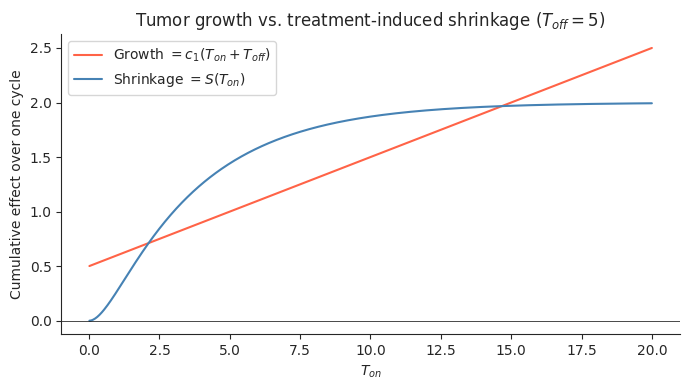

λ1 = -0.2929,  λ2 = -1.7071
K1 = -0.7071
S_inf = 2.0000


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ── Parameters (from parameter cell above) ───────────────────────────
T_off = 5.0          # Toff = 5 * tau_off, where tau_off = 1/|lambda_off| = 1

# On-treatment eigenvalues
disc = b2**2 - 4 * a1 * b1_on
lam1 = (-b2 + np.sqrt(disc)) / 2   # less negative
lam2 = (-b2 - np.sqrt(disc)) / 2   # more negative

# K1 constant
K1 = b2 * mu * (b1_on / b1 - 1) / (lam1 - lam2)

# ── Curves as functions of Ton ────────────────────────────────────────
Ton = np.linspace(0.01, 20, 500)

growth   = c1 * (Ton + T_off)
shrinkage = -c2 * K1 * (
    np.exp(lam1 * Ton) / lam1 - np.exp(lam2 * Ton) / lam2
    - 1/lam1 + 1/lam2
)

# ── Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(Ton, growth,    label=r'Growth $= c_1(T_{on} + T_{off})$',    color='tomato')
ax.plot(Ton, shrinkage, label=r'Shrinkage $= S(T_{on})$', color='steelblue')

ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel(r'$T_{on}$')
ax.set_ylabel('Cumulative effect over one cycle')
ax.set_title(r'Tumor growth vs. treatment-induced shrinkage ($T_{off}=5$)')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"λ1 = {lam1:.4f},  λ2 = {lam2:.4f}")
print(f"K1 = {K1:.4f}")
print(f"S_inf = {-c2 * K1 * (-1/lam1 + 1/lam2):.4f}")

### Numeric Optimization of $T_{on}$ and $T_{off}$ over multiple cycles

In [ ]:
from scipy.optimize import minimize
from matplotlib.colors import TwoSlopeNorm, Normalize

T_horizon_abc = 60.0  # total ABC treatment horizon

def J_horizon(Ton, Toff):
    """Avg shrinkage rate over fixed time horizon (maximise → more shrinkage)."""
    def rhs(y, t, b1_val):
        A, B, _, I = y
        return [a1*(mu - B), b1_val*A - b2*B, 0.0, max(mu - B, 0)]

    y_cur = [A_ss, B_ss, 1.0, 0.0]
    t_elapsed = 0.0
    while t_elapsed < T_horizon_abc:
        t_on = min(Ton, T_horizon_abc - t_elapsed)
        y_cur = odeint(lambda y, t: rhs(y, t, b1_on), y_cur, [0, t_on])[-1]
        t_elapsed += t_on
        if t_elapsed >= T_horizon_abc:
            break
        t_off = min(Toff, T_horizon_abc - t_elapsed)
        y_cur = odeint(lambda y, t: rhs(y, t, b1), y_cur, [0, t_off])[-1]
        t_elapsed += t_off
    return y_cur[3] / T_horizon_abc

# ── 2D heatmap ────────────────────────────────────────────────────────
Ton_grid  = np.linspace(0.5, 12, 30)
Toff_grid = np.linspace(0.5, 12, 30)
J_grid    = np.array([[J_horizon(ton, toff) for toff in Toff_grid] for ton in Ton_grid])

# ── Joint optimization ────────────────────────────────────────────────
best_idx = np.unravel_index(np.nanargmax(J_grid), J_grid.shape)
res = minimize(
    lambda x: -J_horizon(x[0], x[1]),
    x0=[Ton_grid[best_idx[0]], Toff_grid[best_idx[1]]],
    bounds=[(0.1, 20), (0.1, 20)],
    method='L-BFGS-B'
)
Ton_opt, Toff_opt = res.x
J_opt = -res.fun
print(f"Optimal Ton = {Ton_opt:.3f},  Toff = {Toff_opt:.3f},  J* = {J_opt:.5f}")

fig, ax = plt.subplots(figsize=(6, 5))
thresh = c1 / c2
vmin_val, vmax_val = np.nanmin(J_grid), np.nanmax(J_grid)
if vmin_val < thresh < vmax_val:
    norm   = TwoSlopeNorm(vcenter=thresh, vmin=vmin_val, vmax=vmax_val)
    levels = np.linspace(vmin_val, vmax_val, 41)
elif vmin_val >= thresh:   # all shrinkage — white at thresh, red above
    norm   = Normalize(vmin=2*thresh - vmax_val, vmax=vmax_val)
    levels = np.linspace(thresh, vmax_val, 41)
else:                       # all growth — blue below, white at thresh
    norm   = Normalize(vmin=vmin_val, vmax=2*thresh - vmin_val)
    levels = np.linspace(vmin_val, thresh, 41)
im = ax.contourf(Toff_grid, Ton_grid, J_grid, levels=levels, cmap='RdBu_r', norm=norm)
fig.colorbar(im, ax=ax, label=r'$J(T_{on}, T_{off})$')
if vmin_val < thresh < vmax_val:
    ax.contour(Toff_grid, Ton_grid, J_grid,
               levels=[thresh], colors='grey', linewidths=1.2, linestyles='--')
ax.plot(Toff_opt, Ton_opt, 'r*', ms=12,
        label=f'Optimum\n$T_{{on}}={Ton_opt:.2f}$, $T_{{off}}={Toff_opt:.2f}$')
ax.set_xlabel(r'$T_{off}$')
ax.set_ylabel(r'$T_{on}$')
ax.set_title(rf'$J(T_{{on}}, T_{{off}})$, horizon $T={T_horizon_abc}$'
             '\n(grey dashed: shrinkage threshold $c_1/c_2$)')
ax.legend(fontsize=8, loc='upper right')
clean_ax(ax)
plt.tight_layout()
plt.show()


In [ ]:
# ======================================================================
# Multi-cycle simulation using jointly optimal Ton and Toff
# ======================================================================
print(f"Ton = {Ton_opt:.3f},  Toff = {Toff_opt:.3f},  cycle duration = {Ton_opt + Toff_opt:.3f}")

t_all, A_all, B_all, C_all = [], [], [], []
on_spans = []
y_cur = [A_ss, B_ss, 1.0]
t_cur = 0.0

while t_cur < T_horizon_abc:
    # ON phase
    t_on = min(Ton_opt, T_horizon_abc - t_cur)
    t_seg = np.linspace(0, t_on, 300)
    s_on = odeint(lambda y, t: abc_rhs(t, y, b1_on), y_cur, t_seg)
    on_spans.append((t_cur, t_cur + t_on))
    t_all.append(t_cur + t_seg);  A_all.append(s_on[:,0]);  B_all.append(s_on[:,1]);  C_all.append(s_on[:,2])
    t_cur += t_on;  y_cur = s_on[-1]
    if t_cur >= T_horizon_abc:
        break
    # OFF phase
    t_off = min(Toff_opt, T_horizon_abc - t_cur)
    t_seg = np.linspace(0, t_off, 300)
    s_off = odeint(lambda y, t: abc_rhs(t, y, b1), y_cur, t_seg)
    t_all.append(t_cur + t_seg);  A_all.append(s_off[:,0]);  B_all.append(s_off[:,1]);  C_all.append(s_off[:,2])
    t_cur += t_off;  y_cur = s_off[-1]

t_cyc = np.concatenate(t_all)
A_cyc = np.concatenate(A_all)
B_cyc = np.concatenate(B_all)
C_cyc = np.concatenate(C_all)

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True, gridspec_kw={'hspace': 0.1})

for t_start, t_end in on_spans:
    for ax in axes:
        ax.axvspan(t_start, t_end, color='lightgray', alpha=0.4, lw=0, zorder=0)

for ax in axes:
    clean_ax(ax)

axes[0].plot(t_cyc, A_cyc, color='C1', lw=1.5)
axes[0].axhline(A_ss,    color='C1', ls=':',  lw=1.0, alpha=0.5, label=f'$A_{{ss}}$ off = {A_ss:.1f}')
axes[0].axhline(A_ss_on, color='C1', ls='--', lw=1.0, alpha=0.7, label=f'$A_{{ss}}$ on  = {A_ss_on:.1f}')
axes[0].set_ylabel('$A$\n(adaptation)')
axes[0].legend(fontsize=8, loc='upper left')

axes[1].plot(t_cyc, B_cyc, color='C0', lw=1.5)
axes[1].axhline(mu, color='C0', ls='--', lw=1.0, alpha=0.5, label=f'$\\mu$ = {mu:.1f}')
axes[1].set_ylabel('$B$\n(TME component)')
axes[1].legend(fontsize=8, loc='lower right')

axes[2].plot(t_cyc, C_cyc, color='C3', lw=1.5)
axes[2].set_ylabel('$C$\n(tumor size)')
axes[2].set_xlabel('Time')
axes[2].set_ylim(bottom=0)

axes[0].set_title(
    f'Optimal cycling: $T_{{on}}={Ton_opt:.2f}$, $T_{{off}}={Toff_opt:.2f}$, horizon $T={T_horizon_abc}$',
    fontsize=10)

plt.tight_layout()
fig.savefig('abc_model_optimal_cycling.pdf', bbox_inches='tight')
plt.show()


# Extended VEGF Model with Dynamic Tumor

We now extend the model by making the tumor size $C$ a fully dynamic variable and coupling it to a vascular signaling system. The system has four state variables:

- $A_1$: VEGF (pro-angiogenic signal)
- $A_2$: compensatory angiogenic signal
- $E$: endothelial cells (vasculature)
- $C$: tumor size

$$\frac{dA_1}{dt} = k_1(\mu C - E)$$
$$\frac{dA_2}{dt} = k_2(\mu C - E)$$
$$\frac{dE}{dt} = E \left[ (a_1 A_1 + a_2 A_2)\left(1 - \frac{E}{4\mu C}\right) - r_E \right]$$
$$\frac{dC}{dt} = C \bigl(c_1 - c_2 \max(\mu C - E,\, 0)\bigr)$$

The quantity $\mu C - E$ is the **vascular deficit**: when positive, the tumor is under-vascularized. Both signals $A_1$ and $A_2$ are driven upward by this deficit (integral feedback). $E$ grows logistically in response to these signals, with carrying capacity $4\mu C$.

**Treatment** blocks the VEGF pathway by setting $a_1 = 0$. This weakens the drive to grow vasculature, causing $E$ to fall below $\mu C$. The resulting deficit activates the tumor removal term $c_2(\mu C - E)$, shrinking the tumor.

In [12]:
# ======================================================================
# VEGF model parameters
# ======================================================================
k1   = 5.0    # A1 (VEGF) production rate
k2   = 5.0    # A2 (compensatory signal) production rate
a1_v = 0.5    # VEGF effect on E growth (set to 0 during treatment)
a2_v = 0.1    # compensatory signal effect on E growth
r_E  = 0.5    # endothelial cell death rate
mu_v = 0.25   # vascular scaling factor (E_ss = mu_v * C at steady state)
c1_v = 0.1   # tumor growth rate
c2_v = 1.0    # tumor removal rate (active when mu_v*C > E)

# ── Steady state at C0 ───────────────────────────────────────────────
# At SS: deficit = mu_v*C - E = 0  →  E_ss = mu_v * C0
# dE/dt = 0: (a1_v*A1 + a2_v*A2) * (1 - 1/4) = r_E
#            → a1_v*A1 + a2_v*A2 = 4*r_E/3 ≈ 0.667
# Values below taken from numerical SS of VEGF notebook (C0=16)
C0_v  = 16.0
E0_v  = mu_v * C0_v           # = 4.0
A1_0  = 1.2963
A2_0  = 0.1852
y0_v  = [A1_0, A2_0, E0_v, C0_v]

print(f"Initial state:  A1={A1_0:.4f}, A2={A2_0:.4f}, E={E0_v:.2f}, C={C0_v:.2f}")
print(f"Deficit at t=0: mu_v*C - E = {mu_v*C0_v - E0_v:.4f}  (should be ~0)")

# ── ODE ──────────────────────────────────────────────────────────────
def vegf_rhs(t, y, a1_val):
    A1, A2, E, C = y
    deficit = mu_v * C - E
    dA1 = k1 * deficit
    dA2 = k2 * deficit
    dE  = E * ((a1_val * A1 + a2_v * A2) * (1 - E / (4 * mu_v * C0_v)) - r_E)
    dC  = C * (c1_v - c2_v * max(deficit, 0))
    return [dA1, dA2, dE, dC]

Initial state:  A1=1.2963, A2=0.1852, E=4.00, C=16.00
Deficit at t=0: mu_v*C - E = 0.0000  (should be ~0)


In [ ]:
from scipy.optimize import minimize
from scipy.integrate import solve_ivp
from matplotlib.colors import TwoSlopeNorm, Normalize

T_horizon_v = 100.0  # total dimensional VEGF treatment horizon

def _integrate_v(y0, T, a1_val, rtol=1e-4, atol=1e-7):
    """Integrate vegf_rhs over [0, T]. Returns None if integration fails or diverges."""
    sol = solve_ivp(
        lambda t, y: vegf_rhs(t, y, a1_val),
        (0, T), y0, method='RK45', rtol=rtol, atol=atol,
    )
    result = list(sol.y[:, -1])
    if not all(np.isfinite(v) for v in result):
        return None
    return result

def J_horizon_v(Ton, Toff):
    """Log-fold change in tumor size over fixed time horizon (negative = shrinkage)."""
    y_cur = list(y0_v)
    C_init = y_cur[3]
    t_elapsed = 0.0
    while t_elapsed < T_horizon_v:
        t_on = min(Ton, T_horizon_v - t_elapsed)
        y_cur = _integrate_v(y_cur, t_on, 0.0)
        if y_cur is None: return np.nan
        t_elapsed += t_on
        if t_elapsed >= T_horizon_v:
            break
        t_off = min(Toff, T_horizon_v - t_elapsed)
        y_cur = _integrate_v(y_cur, t_off, a1_v)
        if y_cur is None: return np.nan
        t_elapsed += t_off
    val = np.log(y_cur[3] / C_init)
    return val if np.isfinite(val) else np.nan

# ── 2D heatmap ────────────────────────────────────────────────────────
Ton_grid_v  = np.linspace(0.5, 20, 30)
Toff_grid_v = np.linspace(0.5, 20, 30)
J_grid_v = np.array([[J_horizon_v(ton, toff)
                       for toff in Toff_grid_v]
                      for ton  in Ton_grid_v])

n_failed = np.sum(~np.isfinite(J_grid_v))
print(f"Heatmap computed. Failed points (NaN): {n_failed} / {J_grid_v.size}")

# ── Joint optimization ────────────────────────────────────────────────
best_idx = np.unravel_index(np.nanargmin(J_grid_v), J_grid_v.shape)
res_v = minimize(
    lambda x: J_horizon_v(x[0], x[1]),
    x0=[Ton_grid_v[best_idx[0]], Toff_grid_v[best_idx[1]]],
    bounds=[(0.1, 30), (0.1, 30)],
    method='L-BFGS-B'
)
Ton_opt_v, Toff_opt_v = res_v.x
J_opt_v = res_v.fun
print(f"Optimal Ton = {Ton_opt_v:.3f},  Toff = {Toff_opt_v:.3f},  log(C_final/C_init) = {J_opt_v:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
J_masked = np.ma.masked_invalid(J_grid_v)
vmin_val, vmax_val = np.nanmin(J_grid_v), np.nanmax(J_grid_v)
if vmin_val < 0 < vmax_val:
    norm   = TwoSlopeNorm(vcenter=0.0, vmin=vmin_val, vmax=vmax_val)
    levels = np.linspace(vmin_val, vmax_val, 41)
elif vmin_val >= 0:
    norm   = Normalize(vmin=-vmax_val, vmax=vmax_val)
    levels = np.linspace(0.0, vmax_val, 41)
else:
    norm   = Normalize(vmin=vmin_val, vmax=-vmin_val)
    levels = np.linspace(vmin_val, 0.0, 41)
im = ax.contourf(Toff_grid_v, Ton_grid_v, J_masked, levels=levels, cmap='RdBu_r', norm=norm)
fig.colorbar(im, ax=ax, label=r'$\log(C_{final}/C_{init})$')
if vmin_val < 0 < vmax_val:
    ax.contour(Toff_grid_v, Ton_grid_v, J_masked,
               levels=[0], colors='grey', linewidths=1.2, linestyles='--')
ax.plot(Toff_opt_v, Ton_opt_v, 'r*', ms=12,
        label=f'Optimum\n$T_{{on}}={Ton_opt_v:.2f}$, $T_{{off}}={Toff_opt_v:.2f}$')
ax.set_xlabel(r'$T_{off}$')
ax.set_ylabel(r'$T_{on}$')
ax.set_title(rf'VEGF model — $\log(C_{{final}}/C_{{init}})$, horizon $T={T_horizon_v}$'
             '\n(grey dashed: break-even)')
ax.legend(fontsize=8, loc='upper right')
clean_ax(ax)
plt.tight_layout()
plt.show()


In [ ]:
# ======================================================================
# Multi-cycle simulation (arbitrary Ton, Toff)
# ======================================================================
# Ton_v  = Ton_opt_v
# Toff_v = Toff_opt_v
Ton_v  = 4.0
Toff_v = 4.0
print(f"Simulating with Ton={Ton_v:.2f}, Toff={Toff_v:.2f}")

t_all, A1_all, A2_all, E_all, C_all = [], [], [], [], []
on_spans = []
y_cur = list(y0_v)
t_cur = 0.0

while t_cur < T_horizon_v:
    # ON phase (a1 blocked → a1_val = 0)
    t_on = min(Ton_v, T_horizon_v - t_cur)
    t_seg = np.linspace(0, t_on, 300)
    sol = odeint(lambda y, t: vegf_rhs(t, y, 0.0), y_cur, t_seg)
    on_spans.append((t_cur, t_cur + t_on))
    t_all.append(t_cur + t_seg)
    A1_all.append(sol[:, 0]);  A2_all.append(sol[:, 1])
    E_all.append(sol[:, 2]);   C_all.append(sol[:, 3])
    t_cur += t_on;  y_cur = list(sol[-1])
    if t_cur >= T_horizon_v:
        break
    # OFF phase (a1 restored)
    t_off = min(Toff_v, T_horizon_v - t_cur)
    t_seg = np.linspace(0, t_off, 300)
    sol = odeint(lambda y, t: vegf_rhs(t, y, a1_v), y_cur, t_seg)
    t_all.append(t_cur + t_seg)
    A1_all.append(sol[:, 0]);  A2_all.append(sol[:, 1])
    E_all.append(sol[:, 2]);   C_all.append(sol[:, 3])
    t_cur += t_off;  y_cur = list(sol[-1])

t_v  = np.concatenate(t_all)
A1_v = np.concatenate(A1_all)
A2_v = np.concatenate(A2_all)
E_v  = np.concatenate(E_all)
C_v  = np.concatenate(C_all)

# ── Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True,
                         gridspec_kw={'hspace': 0.08})

for t_start, t_end in on_spans:
    for ax in axes:
        ax.axvspan(t_start, t_end, color='lightgray', alpha=0.4, lw=0, zorder=0)

for ax in axes:
    clean_ax(ax)

axes[0].plot(t_v, A1_v, color='C0', lw=1.5, label='$A_1$ (VEGF)')
axes[0].plot(t_v, A2_v, color='C1', lw=1.5, label='$A_2$ (compensatory)')
axes[0].set_ylabel('Signals\n$A_1,\\ A_2$')
axes[0].legend(fontsize=8, loc='upper left')

axes[1].plot(t_v, E_v,            color='C2', lw=1.5)
axes[1].plot(t_v, mu_v * C_v, color='C3', lw=1.2, ls='--', label=r'$\mu C$ (target)')
axes[1].set_ylabel('Vasculature\n$E$')
axes[1].legend(fontsize=8, loc='upper left')

axes[2].plot(t_v, mu_v * C_v - E_v, color='C4', lw=1.5)
axes[2].axhline(0, color='k', lw=0.6, ls=':')
axes[2].set_ylabel('Deficit\n$\\mu C - E$')

axes[3].plot(t_v, C_v, color='C3', lw=1.5)
axes[3].set_ylabel('Tumor\n$C$')
axes[3].set_xlabel('Time')
axes[3].set_ylim(bottom=0)

axes[0].set_title(
    f'VEGF model — cyclic treatment  '
    f'($T_{{on}}={Ton_v:.0f}$, $T_{{off}}={Toff_v:.0f}$, horizon $T={T_horizon_v}$)',
    fontsize=10)

plt.tight_layout()
plt.show()

print(f"Initial C = {C_v[0]:.3f},  Final C = {C_v[-1]:.3f}")


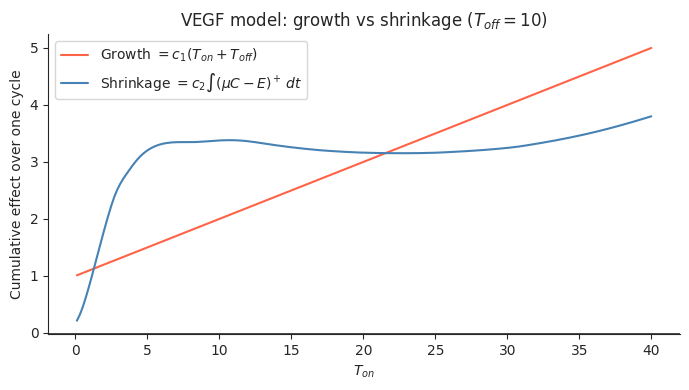

In [15]:
# ── Growth vs shrinkage over a single cycle (fixed Toff) ─────────────
Toff_plot_v = 10.0
Ton_scan    = np.linspace(0.1, 40, 200)

growth_v    = c1_v * (Ton_scan + Toff_plot_v)
shrinkage_v = np.empty_like(Ton_scan)

for i, ton in enumerate(Ton_scan):
    y_cur = _integrate_v(list(y0_v), ton,         0.0)
    y_cur = _integrate_v(y_cur,      Toff_plot_v, a1_v)
    log_fold = np.log(y_cur[3] / y0_v[3])
    shrinkage_v[i] = growth_v[i] - log_fold   # = c2_v * integral(max(deficit,0))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(Ton_scan, growth_v,    color='tomato',    label=r'Growth $= c_1(T_{on} + T_{off})$')
ax.plot(Ton_scan, shrinkage_v, color='steelblue', label=r'Shrinkage $= c_2 \int (\mu C - E)^+\,dt$')
ax.axhline(0, color='k', linewidth=0.5)
ax.set_xlabel(r'$T_{on}$')
ax.set_ylabel('Cumulative effect over one cycle')
ax.set_title(rf'VEGF model: growth vs shrinkage ($T_{{off}}={Toff_plot_v:.0f}$)')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Non-Dimensionalized VEGF Model

## Characteristic Scales

We rescale variables to remove units and expose the underlying parameter ratios:

| Variable | Scale | Dimensionless |
|---|---|---|
| Time $t$ | $1/r_E$ | $\tau = t \cdot r_E$ |
| Tumor $C$ | $C_0$ | $c = C/C_0$ |
| Vasculature $E$ | $\mu_v C_0$ | $e = E/(\mu_v C_0)$ |
| Signal $A_1$ | $r_E / a_{1,v}$ | $x_1 = A_1 \cdot a_{1,v}/r_E$ |
| Signal $A_2$ | $r_E / a_{2,v}$ | $x_2 = A_2 \cdot a_{2,v}/r_E$ |

## Dimensionless ODEs

The deficit $\mu_v C - E = \mu_v C_0 (c - e)$ appears throughout. Substituting the scaled variables collapses the 10 original parameters into 4 dimensionless groups:

$$\frac{dx_1}{d\tau} = \kappa_1 (c - e)$$
$$\frac{dx_2}{d\tau} = \kappa_2 (c - e)$$
$$\frac{de}{d\tau} = e \left[ (x_1 + x_2)\left(1 - \frac{e}{4}\right) - 1 \right]$$
$$\frac{dc}{d\tau} = c \left[ \gamma_1 - \gamma_2 \max(c - e,\, 0) \right]$$

**Treatment** (blocking $a_1$) sets $x_1$'s contribution to the $e$ equation to zero: $x_1 + x_2 \to x_2$ in the $\dot{e}$ equation. Note that $x_1$ still integrates the deficit — VEGF is still produced in response to hypoxia, it just can't signal.

## Dimensionless Groups

$$\kappa_1 = \frac{k_1\, a_{1,v}\, \mu_v C_0}{r_E^2}, \quad \kappa_2 = \frac{k_2\, a_{2,v}\, \mu_v C_0}{r_E^2}, \quad \gamma_1 = \frac{c_{1,v}}{r_E}, \quad \gamma_2 = \frac{c_{2,v}\, \mu_v C_0}{r_E}$$

With the current parameter values these evaluate to $\kappa_1=40$, $\kappa_2=8$, $\gamma_1=0.2$, $\gamma_2=8$, encoding three key biological assumptions:
1. **Angiogenesis is faster than tumor growth** ($\gamma_1 = 0.2 < 1$): vessels remodel 5× faster than the tumor expands.
2. **Compensatory pathway is weaker** ($\kappa_2/\kappa_1 = 0.2$): the resistance signal is 20% as potent as primary VEGF.
3. **Hypoxia kills faster than the tumor grows** ($\gamma_2 \gg \gamma_1$): a vascular deficit kills the tumor far more rapidly than it can proliferate.

In [44]:
# ======================================================================
# Dimensionless parameters (derived from dimensional ones)
# ======================================================================
kappa1 = k1  * a1_v * mu_v * C0_v / r_E**2 # = 40.0
kappa2 = k2  * a2_v * mu_v * C0_v / r_E**2 # = 8.0
gamma1 = c1_v / r_E # 0.2
gamma2 = c2_v * mu_v * C0_v / r_E

print(f"κ₁ = {kappa1:.2f}  (primary VEGF gain)")
print(f"κ₂ = {kappa2:.2f}  (compensatory signal gain)")
print(f"γ₁ = {gamma1:.2f}  (relative tumor growth rate)")
print(f"γ₂ = {gamma2:.2f}  (tumor necrosis sensitivity)")

# ── Dimensionless initial conditions ─────────────────────────────────
x1_0 = A1_0 * a1_v / r_E
x2_0 = A2_0 * a2_v / r_E
e_0  = E0_v / (mu_v * C0_v)
c_0  = 1.0
y0_dl = [x1_0, x2_0, e_0, c_0]

print(f"\nDimensionless IC: x1={x1_0:.4f}, x2={x2_0:.4f}, e={e_0:.4f}, c={c_0:.4f}")
print(f"x1 + x2 = {x1_0 + x2_0:.4f}  (should equal 4/3 ≈ {4/3:.4f} at SS)")

# ── Dimensionless ODE ─────────────────────────────────────────────────
def vegf_dimless_rhs(tau, y, treated):
    x1, x2, e, c = y
    deficit = c - e
    dx1 = kappa1 * deficit
    dx2 = kappa2 * deficit
    signal = (0.0 if treated else x1) + x2   # x1 blocked during treatment
    de  = e * (signal * (1 - e / 4) - 1)
    dc  = c * (gamma1 - gamma2 * max(deficit, 0))
    return [dx1, dx2, de, dc]

κ₁ = 40.00  (primary VEGF gain)
κ₂ = 8.00  (compensatory signal gain)
γ₁ = 0.20  (relative tumor growth rate)
γ₂ = 8.00  (tumor necrosis sensitivity)

Dimensionless IC: x1=1.2963, x2=0.0370, e=1.0000, c=1.0000
x1 + x2 = 1.3333  (should equal 4/3 ≈ 1.3333 at SS)


Heatmap computed. Failed points (NaN): 0 / 900
Optimal τ_on = 2.195,  τ_off = 1.247,  log(c_final/c_init) = -3.6621


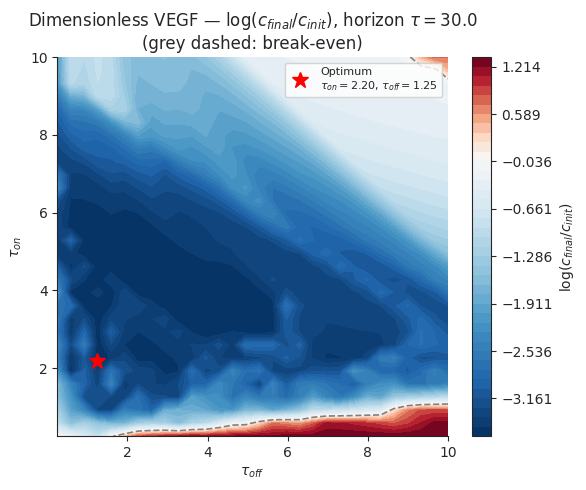

In [45]:
from scipy.optimize import minimize
from matplotlib.colors import TwoSlopeNorm, Normalize

T_horizon = 30.0  # total dimensionless treatment horizon

def _integrate_dl(y0, T, delta, rtol=1e-4, atol=1e-7):
    """Integrate vegf_dimless_rhs over [0, T]. Returns None on failure."""
    sol = solve_ivp(
        lambda tau, y: vegf_dimless_rhs(tau, y, delta),
        (0, T), y0, method='RK45', rtol=rtol, atol=atol,
    )
    result = list(sol.y[:, -1])
    if not all(np.isfinite(v) for v in result):
        return None
    return result

def J_horizon_dl(tau_on, tau_off):
    """Log-fold change in tumor size over a fixed time horizon (negative = shrinkage).
    Cycles on/off until T_horizon, truncating the last phase if needed."""
    y_cur = list(y0_dl)
    c_init = y_cur[3]
    t_elapsed = 0.0
    while t_elapsed < T_horizon:
        # ON phase
        t_on = min(tau_on, T_horizon - t_elapsed)
        y_cur = _integrate_dl(y_cur, t_on, True)
        if y_cur is None: return np.nan
        t_elapsed += t_on
        if t_elapsed >= T_horizon:
            break
        # OFF phase
        t_off = min(tau_off, T_horizon - t_elapsed)
        y_cur = _integrate_dl(y_cur, t_off, False)
        if y_cur is None: return np.nan
        t_elapsed += t_off
    val = np.log(y_cur[3] / c_init)
    return val if np.isfinite(val) else np.nan

# ── 2D heatmap ────────────────────────────────────────────────────────
tau_on_grid  = np.linspace(0.25, 10, 30)
tau_off_grid = np.linspace(0.25, 10, 30)
J_grid_dl = np.array([[J_horizon_dl(ton, toff)
                        for toff in tau_off_grid]
                       for ton  in tau_on_grid])

n_failed = np.sum(~np.isfinite(J_grid_dl))
print(f"Heatmap computed. Failed points (NaN): {n_failed} / {J_grid_dl.size}")

# ── Joint optimization ────────────────────────────────────────────────
res_dl = minimize(
    lambda x: J_horizon_dl(x[0], x[1]),
    x0=[tau_on_grid[np.unravel_index(np.nanargmin(J_grid_dl), J_grid_dl.shape)[0]],
        tau_off_grid[np.unravel_index(np.nanargmin(J_grid_dl), J_grid_dl.shape)[1]]],
    bounds=[(0.1, 15), (0.1, 15)],
    method='L-BFGS-B'
)
tau_on_opt, tau_off_opt = res_dl.x
J_opt_dl = res_dl.fun
print(f"Optimal τ_on = {tau_on_opt:.3f},  τ_off = {tau_off_opt:.3f},  log(c_final/c_init) = {J_opt_dl:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
J_masked_dl = np.ma.masked_invalid(J_grid_dl)
vmin_val, vmax_val = np.nanmin(J_grid_dl), np.nanmax(J_grid_dl)
# Build norm and levels so that white always lands at 0.
# TwoSlopeNorm handles the mixed case; for one-sided data we use a symmetric
# Normalize (so 0 maps to the white midpoint of RdBu_r) with levels clipped to
# the actual data range so the colorbar only shows the relevant portion.
if vmin_val < 0 < vmax_val:
    norm   = TwoSlopeNorm(vcenter=0.0, vmin=vmin_val, vmax=vmax_val)
    levels = np.linspace(vmin_val, vmax_val, 41)
elif vmin_val >= 0:   # all growth — white at 0, red above
    norm   = Normalize(vmin=-vmax_val, vmax=vmax_val)
    levels = np.linspace(0.0, vmax_val, 41)
else:                  # all shrinkage — blue below, white at 0
    norm   = Normalize(vmin=vmin_val, vmax=-vmin_val)
    levels = np.linspace(vmin_val, 0.0, 41)
im = ax.contourf(tau_off_grid, tau_on_grid, J_masked_dl, levels=levels, cmap='RdBu_r', norm=norm)
fig.colorbar(im, ax=ax, label=r'$\log(c_{final}/c_{init})$')
# only draw break-even contour if zero is within the data range
if vmin_val < 0 < vmax_val:
    ax.contour(tau_off_grid, tau_on_grid, J_masked_dl,
               levels=[0], colors='grey', linewidths=1.2, linestyles='--')
ax.plot(tau_off_opt, tau_on_opt, 'r*', ms=12,
        label=f'Optimum\n$\\tau_{{on}}={tau_on_opt:.2f}$, $\\tau_{{off}}={tau_off_opt:.2f}$')
ax.set_xlabel(r'$\tau_{off}$')
ax.set_ylabel(r'$\tau_{on}$')
ax.set_title(rf'Dimensionless VEGF — $\log(c_{{final}}/c_{{init}})$, horizon $\tau={T_horizon}$'
             '\n(grey dashed: break-even)')
ax.legend(fontsize=8, loc='upper right')
clean_ax(ax)
plt.tight_layout()
plt.show()


Optimal dimensionless:  τ_on=2.195,  τ_off=1.247
Equivalent dimensional: Ton=4.391,  Toff=2.495


/tmp/ipykernel_2356301/2482412743.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


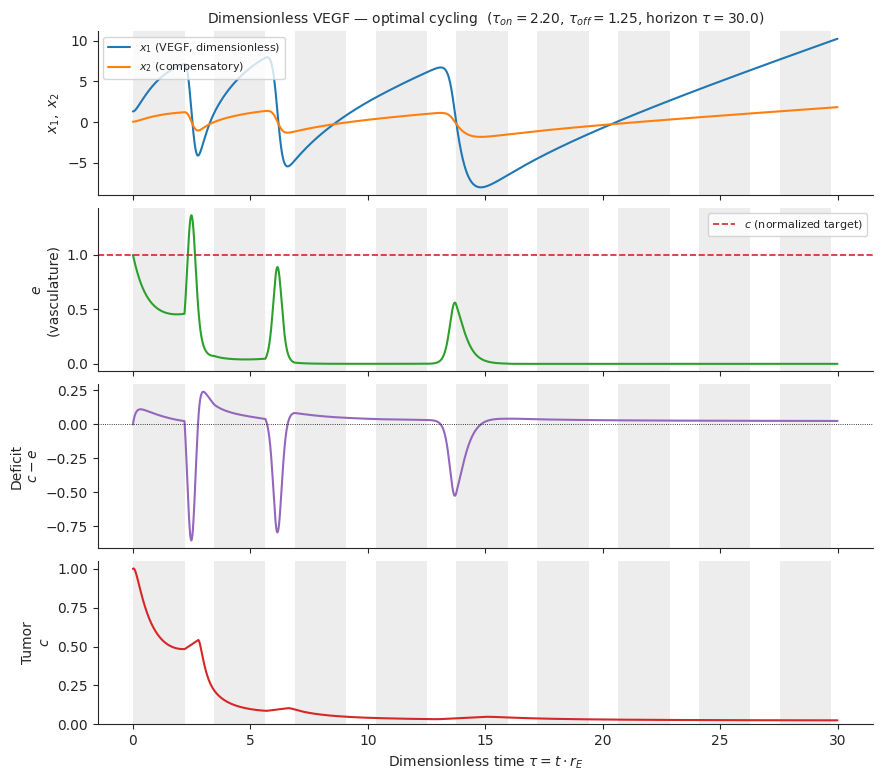

Initial c = 1.0000,  Final c = 0.0257


In [48]:
# ======================================================================
# Multi-cycle simulation in dimensionless time (optimal τ_on, τ_off)
# ======================================================================
Ton_dl  = tau_on_opt
Toff_dl = tau_off_opt
# Ton_dl  = 3.8
# Toff_dl = 2.8
print(f"Optimal dimensionless:  τ_on={Ton_dl:.3f},  τ_off={Toff_dl:.3f}")
print(f"Equivalent dimensional: Ton={Ton_dl/r_E:.3f},  Toff={Toff_dl/r_E:.3f}")

tau_all, x1_all, x2_all, e_all, c_all = [], [], [], [], []
on_spans = []  # for shading treatment-on periods
y_cur = list(y0_dl)
tau_cur = 0.0

while tau_cur < T_horizon:
    # ON phase
    t_on = min(Ton_dl, T_horizon - tau_cur)
    sol = solve_ivp(
        lambda tau, y: vegf_dimless_rhs(tau, y, True),
        (0, t_on), y_cur, method='RK45', rtol=1e-6, atol=1e-9,
        t_eval=np.linspace(0, t_on, 300),
    )
    on_spans.append((tau_cur, tau_cur + t_on))
    tau_all.append(tau_cur + sol.t)
    x1_all.append(sol.y[0]); x2_all.append(sol.y[1])
    e_all.append(sol.y[2]);  c_all.append(sol.y[3])
    tau_cur += t_on
    y_cur = list(sol.y[:, -1])
    if tau_cur >= T_horizon:
        break
    # OFF phase
    t_off = min(Toff_dl, T_horizon - tau_cur)
    sol = solve_ivp(
        lambda tau, y: vegf_dimless_rhs(tau, y, False),
        (0, t_off), y_cur, method='RK45', rtol=1e-6, atol=1e-9,
        t_eval=np.linspace(0, t_off, 300),
    )
    tau_all.append(tau_cur + sol.t)
    x1_all.append(sol.y[0]); x2_all.append(sol.y[1])
    e_all.append(sol.y[2]);  c_all.append(sol.y[3])
    tau_cur += t_off
    y_cur = list(sol.y[:, -1])

tau_v  = np.concatenate(tau_all)
x1_dl  = np.concatenate(x1_all);  x2_dl = np.concatenate(x2_all)
e_dl   = np.concatenate(e_all);   c_dl  = np.concatenate(c_all)

# ── Plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True,
                         gridspec_kw={'hspace': 0.08})

for t_start, t_end in on_spans:
    for ax in axes:
        ax.axvspan(t_start, t_end, color='lightgray', alpha=0.4, lw=0, zorder=0)

for ax in axes:
    clean_ax(ax)

axes[0].plot(tau_v, x1_dl, color='C0', lw=1.5, label='$x_1$ (VEGF, dimensionless)')
axes[0].plot(tau_v, x2_dl, color='C1', lw=1.5, label='$x_2$ (compensatory)')
axes[0].set_ylabel('$x_1,\\ x_2$')
axes[0].legend(fontsize=8, loc='upper left')

axes[1].plot(tau_v, e_dl, color='C2', lw=1.5)
axes[1].axhline(1, color='C3', lw=1.2, ls='--', label='$c$ (normalized target)')
axes[1].set_ylabel('$e$\n(vasculature)')
axes[1].legend(fontsize=8)

axes[2].plot(tau_v, c_dl - e_dl, color='C4', lw=1.5)
axes[2].axhline(0, color='k', lw=0.6, ls=':')
axes[2].set_ylabel('Deficit\n$c - e$')

axes[3].plot(tau_v, c_dl, color='C3', lw=1.5)
axes[3].set_ylabel('Tumor\n$c$')
axes[3].set_xlabel(r'Dimensionless time $\tau = t \cdot r_E$')
axes[3].set_ylim(bottom=0)

axes[0].set_title(
    f'Dimensionless VEGF — optimal cycling  '
    f'($\\tau_{{on}}={Ton_dl:.2f}$, $\\tau_{{off}}={Toff_dl:.2f}$, horizon $\\tau={T_horizon}$)',
    fontsize=10)

plt.tight_layout()
plt.show()

print(f"Initial c = {c_dl[0]:.4f},  Final c = {c_dl[-1]:.4f}")
